# Rectified flow

implementing rectified flow (RF) models on mnist in both pixel and latent spaces

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Pixel-space rectified flow

training a u-net to predict velocity fields directly on images

In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

In [3]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(...,) + (None,) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)


class SimpleUnet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 1
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i + 1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        x = self.conv0(x)
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)

In [4]:
model_rf_pixel = SimpleUnet().to(device)
optimizer = torch.optim.Adam(model_rf_pixel.parameters(), lr=1e-4)
n_epochs = 10

print("Training Pixel-Space rectified flow...")
for epoch in range(n_epochs):
    model_rf_pixel.train()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}")
    epoch_loss = 0
    
    for x1, _ in pbar:
        x1 = x1.to(device)
        batch_size = x1.shape[0]
        
        x0 = torch.randn_like(x1).to(device)
        t = torch.rand(batch_size, device=device)
        t_view = t.view(batch_size, 1, 1, 1)
        
        xt = t_view * x1 + (1 - t_view) * x0
        v_target = x1 - x0
        v_pred = model_rf_pixel(xt, t * 1000)
        
        loss = F.mse_loss(v_pred, v_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    
    print(f"Avg Loss: {epoch_loss / len(dataloader):.4f}")

Training Pixel-Space rectified flow...


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.3931


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.1991


...

Avg Loss: 0.1513


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.1486


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.1475


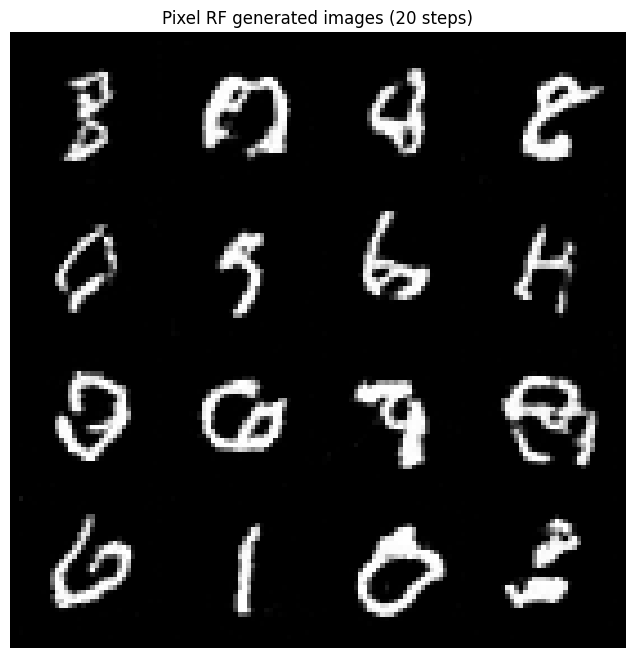

In [5]:
def sample_rf(model, n_samples, channels, image_size, steps=20):
    model.eval()
    dt = 1.0 / steps
    with torch.no_grad():
        x = torch.randn(n_samples, channels, image_size, image_size).to(device)
        for i in range(steps):
            t = torch.ones(n_samples, device=device) * i / steps
            v_pred = model(x, t * 1000)
            x = x + v_pred * dt
        return (x.clamp(-1, 1) + 1) / 2


samples_rf_pixel = sample_rf(model_rf_pixel, 16, 1, 32, steps=20)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Pixel RF generated images (20 steps)")
plt.imshow(make_grid(samples_rf_pixel.cpu(), nrow=4).permute(1, 2, 0))

## Latent-space rectified flow

applying the same logic to learn trajectories in the vae latent space

In [6]:
# reusing definition from prev notebook
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar




vae = VAE(latent_dim=20).to(device)
vae_path = "vae_mnist.pth"

if not os.path.exists(vae_path):
    raise FileNotFoundError(f"VAE checkpoint not found at {vae_path}")

print(f"Loading VAE from {vae_path}")
vae.load_state_dict(torch.load(vae_path, map_location=device))
vae.eval()


Loading VAE from vae_mnist.pth


VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): Sigmoid()
  )
)

Extracting Latents:   0%|          | 0/469 [00:00<?, ?it/s]

Original Stats - Mean: 0.0028, Std: 0.9954
Normalized Stats - Mean: -0.0000, Std: 1.0000


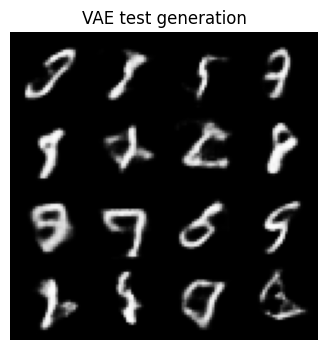

In [10]:
latents = []
with torch.no_grad():
    for x, _ in tqdm(dataloader, desc="Extracting Latents"):
        x = x.to(device)
        x_in = (x + 1) / 2
        x_crop = transforms.CenterCrop(28)(x_in)
        
        mu, logvar = vae.encode(x_crop)
        z = vae.reparameterize(mu, logvar)
        latents.append(z.cpu())



latents = torch.cat(latents, dim=0)

latent_mean = latents.mean(dim=0, keepdim=True)
latent_std = latents.std(dim=0, keepdim=True)

print(f"Original Stats - Mean: {latent_mean.mean():.4f}, Std: {latent_std.mean():.4f}")

latents_norm = (latents - latent_mean) / (latent_std + 1e-6)

print(f"Normalized Stats - Mean: {latents_norm.mean():.4f}, Std: {latents_norm.std():.4f}")

latent_loader = DataLoader(TensorDataset(latents_norm), batch_size=128, shuffle=True)


z_test = torch.randn(16, 20).to(device)
z_test_denorm = z_test * latent_std.to(device) + latent_mean.to(device)

with torch.no_grad():
    imgs = vae.decoder(vae.decoder_input(z_test_denorm)).cpu()

plt.figure(figsize=(4, 4))
plt.imshow(make_grid(imgs, nrow=4).permute(1, 2, 0))
plt.title("VAE test generation")
plt.axis('off')
plt.show()

Training Latent-Space Rectified Flow (with time embeddings)...
Epoch 10, Loss: 1.5033
Epoch 20, Loss: 1.4921
Epoch 30, Loss: 1.4883
Epoch 40, Loss: 1.4843
Epoch 50, Loss: 1.4741
Epoch 60, Loss: 1.4742
Epoch 70, Loss: 1.4729
Epoch 80, Loss: 1.4728
Epoch 90, Loss: 1.4733
Epoch 100, Loss: 1.4735


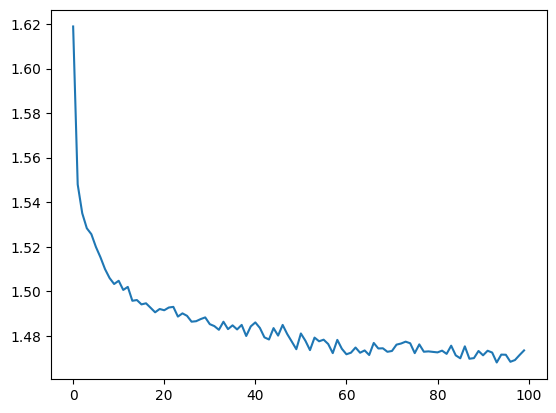

In [8]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        if time.dim() == 2:
            time = time.squeeze(-1)
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class LatentRFMLP(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=512, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        self.input_proj = nn.Linear(latent_dim, hidden_dim)
        
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t * 1000)
        x_emb = self.input_proj(x)
        h = x_emb + t_emb
        return self.net(h)


model_rf_latent = LatentRFMLP().to(device)
optimizer_latent = torch.optim.Adam(model_rf_latent.parameters(), lr=1e-3)

print("Training Latent-Space Rectified Flow (with time embeddings)...")
loss_history = []
for epoch in range(100):
    model_rf_latent.train()
    epoch_loss = 0
    for z1, in latent_loader:
        z1 = z1.to(device)
        batch_size = z1.shape[0]
        
        z0 = torch.randn_like(z1).to(device)
        t = torch.rand(batch_size, 1, device=device)
        
        zt = t * z1 + (1 - t) * z0
        v_target = z1 - z0
        
        v_pred = model_rf_latent(zt, t)
        
        loss = F.mse_loss(v_pred, v_target)
        optimizer_latent.zero_grad()
        loss.backward()
        optimizer_latent.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(latent_loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(loss_history)
plt.show()

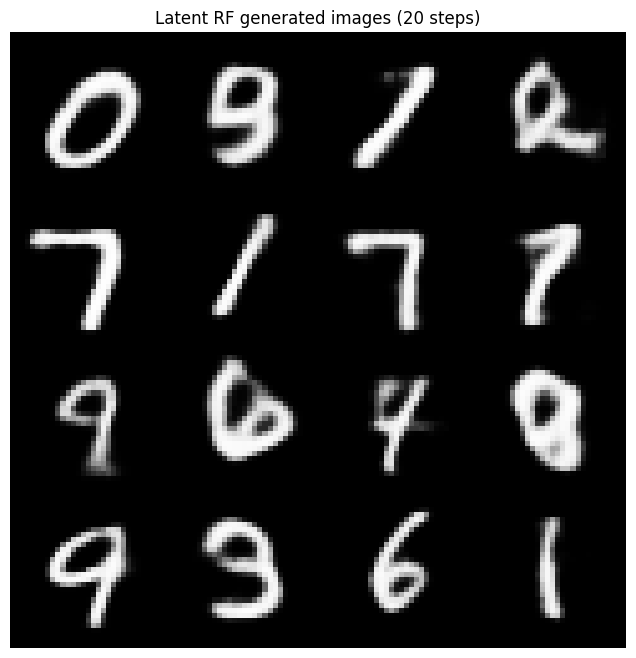

In [9]:
def sample_rf_latent(model, n_samples, latent_dim, steps=20):
    model.eval()
    dt = 1.0 / steps
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim).to(device)
        for i in range(steps):
            t = torch.ones(n_samples, 1, device=device) * i / steps
            v_pred = model(z, t)
            z = z + v_pred * dt
        return z


z_gen = sample_rf_latent(model_rf_latent, 16, 20)

if z_gen.dim() == 3:
    z_gen = z_gen[:, 0, :]

z_gen_denorm = z_gen.cpu() * latent_std + latent_mean
z_gen_denorm = z_gen_denorm.to(device)

with torch.no_grad():
    z_dec = vae.decoder_input(z_gen_denorm)
    imgs = vae.decoder(z_dec).cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Latent RF generated images (20 steps)")
plt.imshow(make_grid(imgs, nrow=4).permute(1, 2, 0))
plt.show()